# Learning by Pruning — Sensitivity Analysis

In [6]:
import sys
import os
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets
from functools import partial
from itertools import product
from tqdm.auto import tqdm

_project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..', '..'))
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from phd.research_utils.analysis.plotting import plot_param_sensitivity

SEED = 42
SCAN_UNROLL = 10
INPUT_SIZE = 784
OUTPUT_SIZE = 10

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ── Load MNIST once ───────────────────────────────────────────────────
train_dataset = datasets.MNIST(root="./data", train=True, download=True)

all_images_np = train_dataset.data.numpy().reshape(-1, 784).astype(np.float32)
all_images_np = (all_images_np / 255.0 - 0.1307) / 0.3081
all_labels_np = train_dataset.targets.numpy()
print(f"Loaded {len(all_labels_np)} training images")

Loaded 60000 training images


In [8]:
# ── Experiment function ───────────────────────────────────────────────

def forward(x, W1, b1, W2, b2, mask):
    h = jax.nn.relu(x @ W1 + b1) * mask
    logits = h @ W2 + b2
    return logits, h


def compute_hidden_utility(h, W2, error):
    c = W2 * h[:, None]
    U = (jnp.abs(error + c) - jnp.abs(error)).sum(axis=1)
    return U


def _make_scan_step(trace_decay):
    """Create a scan step function closed over trace_decay."""
    def _scan_step(carry, data):
        W1, b1, W2, b2, mask, utility_trace = carry
        x, label = data

        logits, h = forward(x, W1, b1, W2, b2, mask)
        correct = (jnp.argmax(logits) == label).astype(jnp.float32)

        one_hot = jax.nn.one_hot(label, OUTPUT_SIZE)
        error = one_hot - logits

        U = compute_hidden_utility(h, W2, error)
        utility_trace = utility_trace * trace_decay + U * (1 - trace_decay)

        carry = (W1, b1, W2, b2, mask, utility_trace)
        return carry, correct
    return _scan_step


# Cache of jitted scan functions keyed by trace_decay
_scan_cache = {}

def _get_scan_fn(trace_decay):
    if trace_decay not in _scan_cache:
        step_fn = _make_scan_step(trace_decay)
        _scan_cache[trace_decay] = jax.jit(
            lambda carry, data: jax.lax.scan(step_fn, carry, data, unroll=SCAN_UNROLL)
        )
    return _scan_cache[trace_decay]


def run_pruning_experiment(
    hidden_size,
    prune_every,
    reset_traces_on_prune,
    seed=SEED,
    pbar=None,
):
    """Run a single learning-by-pruning experiment. Returns dict of results."""
    trace_decay = 1.0 - (1.0 / prune_every)
    n_prune_events = hidden_size

    scan_fn = _get_scan_fn(trace_decay)

    # Initialize weights
    key = jax.random.PRNGKey(seed)
    k1, k2 = jax.random.split(key)
    W1 = jax.random.normal(k1, (INPUT_SIZE, hidden_size)) * np.sqrt(2.0 / INPUT_SIZE)
    b1 = jnp.zeros(hidden_size)
    W2 = jax.random.normal(k2, (hidden_size, OUTPUT_SIZE)) * np.sqrt(2.0 / hidden_size)
    b2 = jnp.zeros(OUTPUT_SIZE)
    mask = jnp.ones(hidden_size)
    utility_trace = jnp.zeros(hidden_size)

    # Data iteration
    rng = np.random.RandomState(seed)
    epoch_order = rng.permutation(len(all_labels_np))
    epoch_pos = 0

    def get_chunk(size):
        nonlocal epoch_order, epoch_pos
        indices = []
        remaining = size
        while remaining > 0:
            avail = len(epoch_order) - epoch_pos
            take = min(avail, remaining)
            indices.append(epoch_order[epoch_pos:epoch_pos + take])
            epoch_pos += take
            remaining -= take
            if epoch_pos >= len(epoch_order):
                epoch_order = rng.permutation(len(all_labels_np))
                epoch_pos = 0
        return np.concatenate(indices)

    all_corrects = []
    n_active_history = []
    carry = (W1, b1, W2, b2, mask, utility_trace)

    for prune_idx in range(n_prune_events):
        indices = get_chunk(prune_every)
        data = (jnp.array(all_images_np[indices]), jnp.array(all_labels_np[indices]))

        carry, corrects = scan_fn(carry, data)
        all_corrects.append(np.array(corrects))

        W1, b1, W2, b2, mask, utility_trace = carry
        n_active = int(mask.sum())
        n_active_history.append(n_active)

        if n_active > 1:
            score = jnp.where(mask > 0.5, utility_trace, jnp.inf)
            worst = jnp.argmin(score)
            mask = mask.at[worst].set(0.0)
            if reset_traces_on_prune:
                utility_trace = jnp.zeros(hidden_size)

        carry = (W1, b1, W2, b2, mask, utility_trace)

        if pbar is not None:
            pbar.update(prune_every)

    # Compute per-interval accuracy
    acc_per_interval = np.array([c.mean() for c in all_corrects])

    return {
        'acc_per_interval': acc_per_interval,
        'n_active_history': np.array(n_active_history),
        'peak_accuracy': float(acc_per_interval.max()) * 100,
        'mean_accuracy': float(acc_per_interval.mean()) * 100,
        'final_accuracy': float(acc_per_interval[-1]) * 100,
    }

In [9]:
EVAL_CHUNK = 1000  # steps per evaluation chunk; best chunk = reported metric

def best_chunk_accuracy(acc_per_interval, prune_every):
    """Average accuracy over the best EVAL_CHUNK-step window."""
    all_correct = np.concatenate([np.full(int(prune_every), a) for a in acc_per_interval])
    n_steps = len(all_correct)
    n_chunks = n_steps // EVAL_CHUNK
    if n_chunks == 0:
        return float(all_correct.mean()) * 100
    # Trim to exact multiple of EVAL_CHUNK
    trimmed = all_correct[:n_chunks * EVAL_CHUNK].reshape(n_chunks, EVAL_CHUNK)
    chunk_accs = trimmed.mean(axis=1)
    return float(chunk_accs.max()) * 100


def run_sweep(configs):
    """
    Run experiments for a list of config dicts.
    Each config must have: hidden_size, prune_every, reset_traces_on_prune.
    Optional: seed (defaults to SEED).

    Returns (run_df, config_df) suitable for plot_param_sensitivity.
    run_df has one row per run with the best-EVAL_CHUNK accuracy as the metric.
    """
    run_rows = []
    config_rows = []

    total_steps = sum(cfg['hidden_size'] * cfg['prune_every'] for cfg in configs)
    pbar = tqdm(total=total_steps, desc='Sweep', unit='step')

    for run_id, cfg in enumerate(configs):
        hidden_size = cfg['hidden_size']
        prune_every = cfg['prune_every']
        reset = cfg['reset_traces_on_prune']
        seed = cfg.get('seed', SEED)

        pbar.set_postfix(h=hidden_size, p=prune_every, reset=reset)

        result = run_pruning_experiment(
            hidden_size=hidden_size,
            prune_every=prune_every,
            reset_traces_on_prune=reset,
            seed=seed,
            pbar=pbar,
        )

        best_acc = best_chunk_accuracy(result['acc_per_interval'], prune_every)

        run_rows.append({
            'run_id': run_id,
            'step': 0,
            'best_chunk_accuracy': best_acc,
        })

        config_rows.append({
            'run_id': run_id,
            'hidden_size': hidden_size,
            'prune_every': prune_every,
            'reset_traces_on_prune': reset,
            'seed': seed,
        })

    pbar.close()

    run_df = pd.DataFrame(run_rows)
    config_df = pd.DataFrame(config_rows)
    return run_df, config_df

## Experiment 1: Hidden Size Sensitivity

How does the number of initial hidden units affect peak pruning performance? Larger networks have more units to prune through, giving the utility signal more opportunities to identify useful features — but they also require more total steps (hidden_size × prune_every). Each point shows the best 1k-step chunk accuracy achieved during the run, with separate lines for whether utility traces are reset after each prune event.

In [10]:
hidden_sizes = [100, 200, 400, 800, 1600, 3200]
reset_values = [False, True]

configs_exp1 = [
    {'hidden_size': h, 'prune_every': 100, 'reset_traces_on_prune': r}
    for h, r in product(hidden_sizes, reset_values)
]

run_df_1, config_df_1 = run_sweep(configs_exp1)

Sweep: 100%|██████████| 1260000/1260000 [01:45<00:00, 11916.02step/s, h=3200, p=100, reset=1]


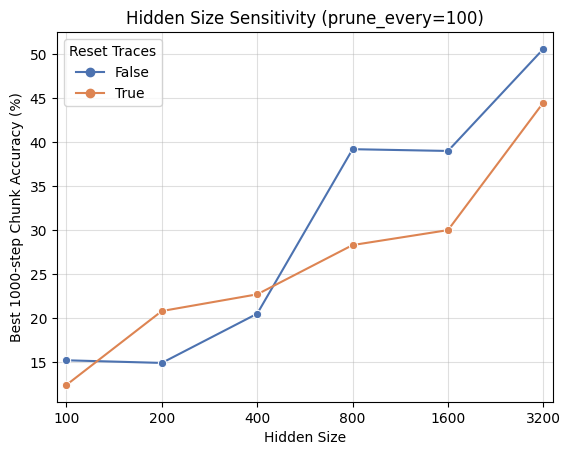

In [11]:
plot_param_sensitivity(
    run_df=run_df_1,
    config_df=config_df_1,
    x_col='hidden_size',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Hidden Size Sensitivity (prune_every=100)',
    x_label='Hidden Size',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)

## Experiment 2: Prune Frequency Sensitivity

How many steps should elapse between pruning events? Too few steps means the utility trace hasn't accumulated enough signal to make a good pruning decision; too many means we waste compute on units that could have been pruned earlier. Hidden size is fixed at 1000. Each point shows the best 1k-step chunk accuracy, with separate lines for reset vs. no-reset of utility traces after pruning.

In [12]:
prune_every_values = [25, 50, 100, 200, 400, 800]

configs_exp2 = [
    {'hidden_size': 1000, 'prune_every': p, 'reset_traces_on_prune': r}
    for p, r in product(prune_every_values, reset_values)
]

run_df_2, config_df_2 = run_sweep(configs_exp2)

Sweep: 100%|██████████| 3150000/3150000 [01:47<00:00, 29411.63step/s, h=1000, p=800, reset=1]


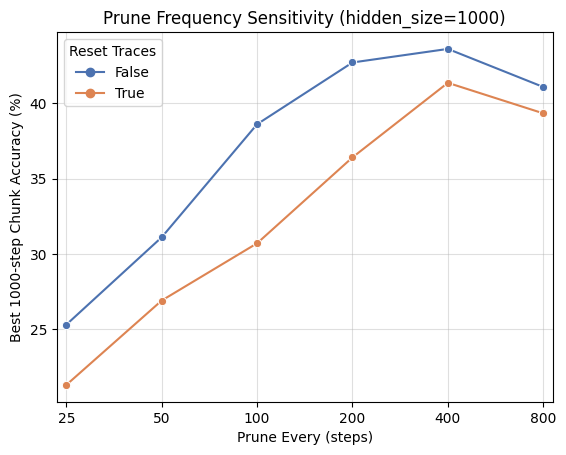

In [13]:
plot_param_sensitivity(
    run_df=run_df_2,
    config_df=config_df_2,
    x_col='prune_every',
    hue_col='reset_traces_on_prune',
    metric_col='best_chunk_accuracy',
    metric_type='last',
    title='Prune Frequency Sensitivity (hidden_size=1000)',
    x_label='Prune Every (steps)',
    y_label=f'Best {EVAL_CHUNK}-step Chunk Accuracy (%)',
    legend_title='Reset Traces',
)